# thalamus: spindle3

In [ ]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

: 

In [ ]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
params = dp.loadDefaultParams(0)
#params["dt"] = 0.0001
#params["Jet"] = 1.98
#params 

In [ ]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


In [ ]:

import yasa
import xarray as xr
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
'''
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)
'''
sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
print("TCR:",sp2.summary()["Duration"]) if sp2 else  print("NO Fast spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate2 = len(sp2._events) / duration if sp2 else 0
print("Fast spindles:", rate2)

sp4 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,13), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.60, "rms":1.5})
print("TCR:",sp4.summary()) if sp4 else  print("NO Slow spindle in TCR")
#len(sp.summary()) # 9.7s, _events 9.5s
rate4 = len(sp4._events) / duration if sp4 else 0
print("Slow spindles:", rate4)



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


10000.0
TCR: 0    0.3136
Name: Duration, dtype: float64
Fast spindles: 0.03333333333333333
TCR:       Start     Peak      End  Duration  Amplitude       RMS  AbsPower  \
0    0.0751   0.0898   0.4182    0.3431   5.219309  1.039561 -0.109452   
1    0.8304   1.0482   1.2881    0.4577   2.384532  0.630830 -0.241950   
2    3.1971   3.6468   3.8293    0.6322   3.623238  0.742294 -0.231882   
3    4.4636   4.6703   4.8680    0.4044   3.774964  0.817846 -0.345448   
4    6.7439   6.8428   7.0563    0.3124   2.547019  0.643920 -0.276369   
5    9.7204   9.9192  10.2037    0.4833   4.756649  0.916304 -0.215192   
6   15.1017  15.1852  15.4678    0.3661   4.281224  0.997646 -0.293771   
7   17.7042  17.9166  18.0677    0.3635   3.509726  0.776762 -0.221313   
8   22.8715  23.0777  23.2028    0.3313   3.263467  0.706554 -0.302993   
9   23.8849  24.1961  24.4286    0.5437   5.062505  1.044905 -0.111418   
10  26.0597  26.3657  26.5514    0.4917   4.592708  0.871645 -0.119911   
11  27.2386  27.

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


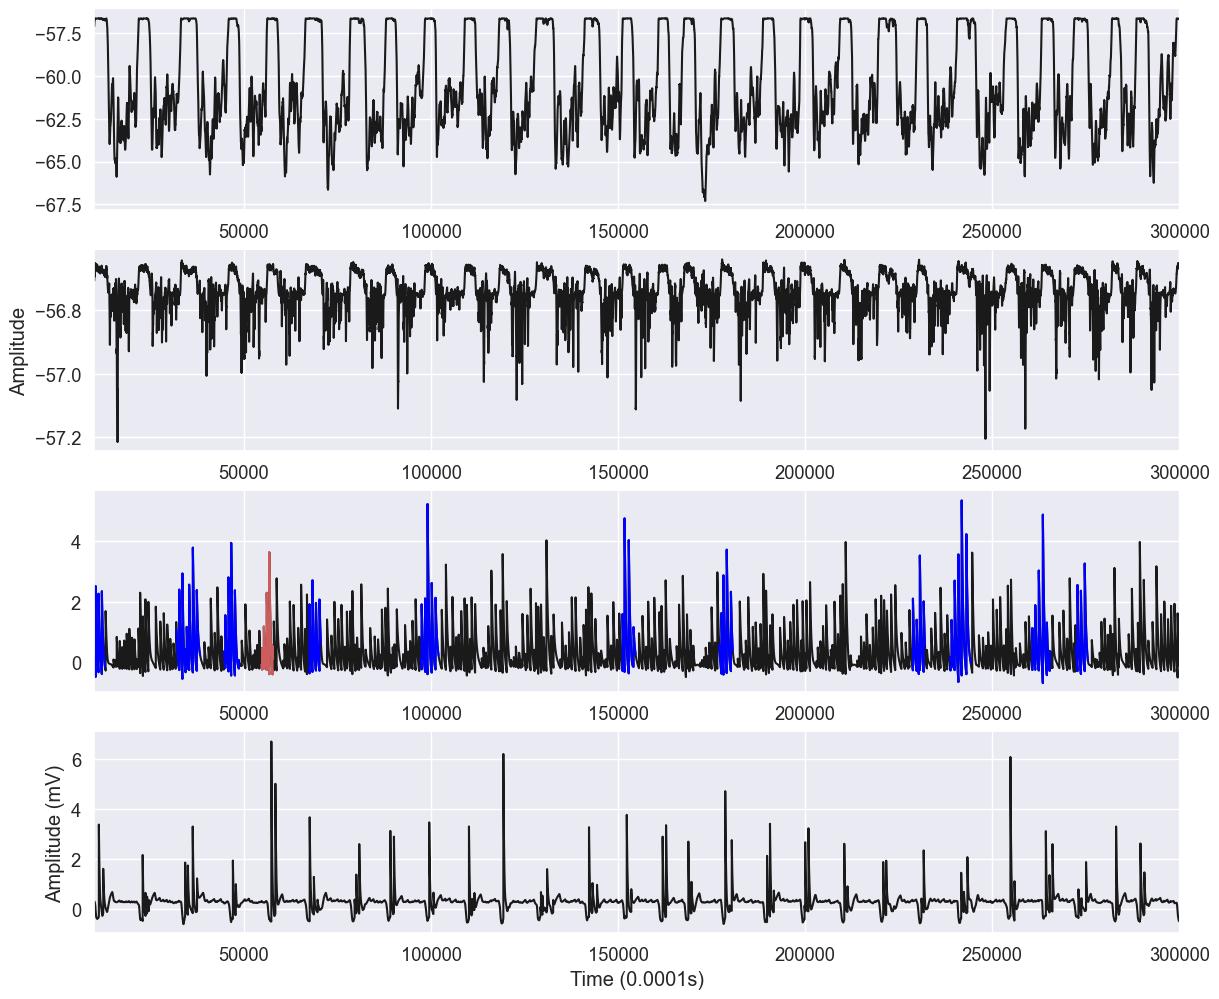

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(4, 1, figsize=(14, 12))

#plt.title('N2 sleep EEG data (2 spindles)')

plt.setp(ax, xlim=(t[10000:].min(), t[10000:].max()))
#plt.setp(ax, xlim=(t[10000:50000].min(), t[10000:50000].max()))
#plt.xlim([t.min(), t.max()])
#plt.xlim([t[10000:].min()/10000, t[10000:].max()/10000])

plt.subplot(4,1,1)
#plt.plot(t[10000:50000], V_e[10000:50000], lw=1.5, color='k')
plt.plot(t[10000:], V_e[10000:], lw=1.5, color='k')
'''
if sp1:
    mask1 = sp1.get_mask()
    spindles_highlight_e = Q_e * mask1
    spindles_highlight_e[spindles_highlight_e == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight_e[10000:]*1000, 'indianred')
'''
plt.subplot(4,1,2)
plt.plot(t[10000:], V_i[10000:], lw=1.5, color='k')
#plt.plot(t, Q_i*1000, lw=1.5, color='k')
plt.ylabel('Amplitude')


plt.subplot(4,1,3)
#plt.plot(t, V_t, lw=1.5, color='k')
plt.plot(t[10000:], V_t[10000:], lw=1.5, color='k')
if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = V_t * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'indianred')

if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = V_t * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'blue')


plt.subplot(4,1,4)
#plt.plot(t, V_r, lw=1.5, color='k')
plt.plot(t[10000:], V_r[10000:], lw=1.5, color='k')
plt.xlabel('Time (0.0001s)')
plt.ylabel('Amplitude (mV)')


sns.despine()

In [ ]:
# for CFC
from statistical_testing import get_p_values
from xfreq import (
    XFreqEvaluateSignal,
    kullback_leibler_modulation_index,
    mean_vector_length,
    mutual_information,
    phase_locking_value,
)
from neurolib.utils.signal import Signal, RatesSignal 
from utils import dummy_detect_down_states, get_amplitude, get_dummy_so_phase, get_phase
import pandas as pd 
import xarray as xr 
from itertools import tee
# for circ
from scipy.stats import circmean, circstd
from spindle_detection import down_state_to_spindle_pow_max_peak
# for TF
from yasa import get_centered_indices, stft_power
import matplotlib as mpl

# 计算静息电位（取前几秒的平均值）
resting_potential = np.mean(V_e[:int(10000 * 5)])  # 前5秒平均
V_e_relative = V_e - (-65)



results_df = pd.DataFrame(
    {
        "ALN": V_e_relative,
        "TCR": V_t, # 这里用Q行吗？
    },
    index=t/10000,
)
results_df.index.name = "time"

aln_xr = xr.DataArray(results_df["ALN"])
tcr_xr = xr.DataArray(results_df["TCR"])
aln_sig = RatesSignal(aln_xr)
tcr_sig = RatesSignal(tcr_xr)


Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 16501 samples (1.650 sec)

(300000,)
(300000,)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


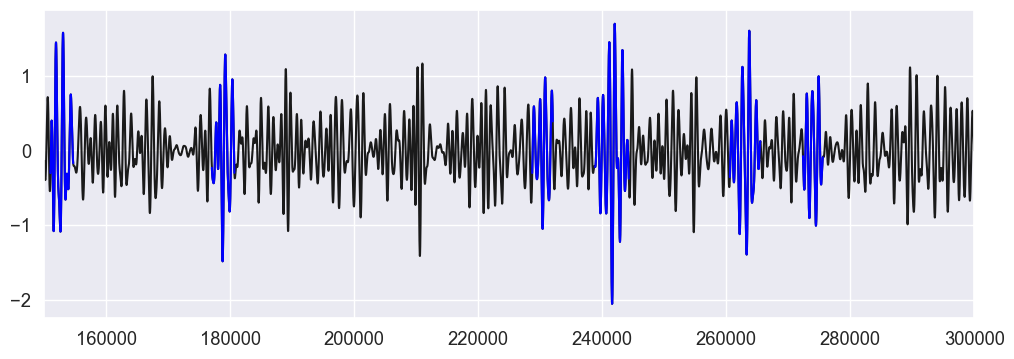

In [ ]:
import matplotlib.pyplot as plt
# V_t after filter (tcr_sig) (how?)
pad = 5.0
filter_args1={"low_freq": 12.0, "high_freq": 16.0}
filter_args2={"low_freq": 8.0, "high_freq": 12.0}
filter_args3={"low_freq": 8.0, "high_freq": 16.0}


tcr_filter = tcr_sig.detrend(inplace=False)
if 0:#pad:
    tcr_filter.pad(
        how_much=pad, in_seconds=True, padding_type="reflect", side="both"
    )
#tcr_filter.filter(**filter_args1)
tcr_filter.filter(**filter_args3)
print(tcr_filter.data.values.shape)
print(t.shape)
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

#plt.setp(ax, xlim=(t[10000:].min(), t[10000:].max()))
plt.setp(ax, xlim=(t[150000:300000].min(), t[150000:300000].max()))

plt.subplot(1,1,1)
#plt.plot(t[10000:110000], tcr_filter.data.values[10000:110000], lw=1.5, color='k')
plt.plot(t[10000:], tcr_filter.data.values[10000:], lw=1.5, color='k')
if sp2:
    mask2 = sp2.get_mask()
    spindles_highlight = tcr_filter.data.values * mask2
    spindles_highlight[spindles_highlight == 0] = np.nan
#    plt.plot(t[10000:110000], spindles_highlight[10000:110000], 'indianred')
    plt.plot(t[10000:], spindles_highlight[10000:], 'indianred')
if sp4:
    mask4 = sp4.get_mask()
    spindles_highlight = tcr_filter.data.values * mask4
    spindles_highlight[spindles_highlight == 0] = np.nan
    plt.plot(t[10000:], spindles_highlight[10000:], 'blue')




node,f,Sxx:  ALN [ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.
 14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20. ] [[0.30787179 0.30791872 0.30796563 ... 0.45103402 0.45098181 0.45092954]
 [0.13228232 0.132285   0.13228769 ... 0.19557048 0.19558857 0.19560667]
 [0.0297511  0.0297455  0.0297399  ... 0.07150758 0.07151398 0.07152039]
 ...
 [0.01147526 0.01147421 0.01147316 ... 0.00064982 0.00064993 0.00065004]
 [0.01178159 0.01178073 0.01177988 ... 0.00050181 0.00050198 0.00050214]
 [0.01152699 0.01152607 0.01152514 ... 0.00101408 0.00101406 0.00101403]]
node,f,Sxx:  TCR [ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5 14.
 14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20. ] [[0.08045962 0.08047076 0.08048188 ... 0.24532263 0.24530774 0.24529283]
 [0.05772454 0.05772399 0.05772344 ... 0.0630

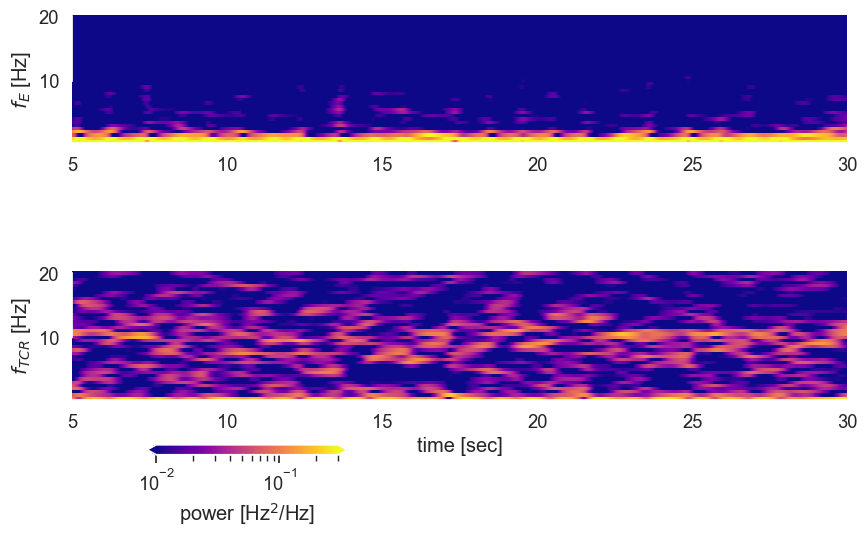

In [ ]:

# TFR plot ALN and TCR (results_df) (how?)
CMAP = "plasma"
SXX_EPS = 1.1e-3

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(nrows=2, ncols=1)
gs.update(wspace=1, hspace=1.0)

sampling_freq = 1.0 / (results_df.index[1] - results_df.index[0])
window = 2.0  # seconds
step = 0.2  # seconds
freqs_bounds = (0.1, 20.0)
vmin = 0.01
vmax = 0.3
stft_axs = []
for ii, node in enumerate(["ALN", "TCR"]):
    f, _, Sxx = stft_power(
        results_df[node],
        sampling_freq,
        window=window,
        step=step,
        band=freqs_bounds,
        norm=True,
        interp=True,
    )
    print("node,f,Sxx: ",node, f, Sxx)
    ax = fig.add_subplot(gs[ii,0])
    stft_axs.append(ax)
    ax.pcolormesh(
        results_df.index,
        f,
        Sxx + SXX_EPS,
        cmap=CMAP,
        rasterized=True,
        norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.grid()
    ax.set_ylabel(f"$f_{{{'TCR' if node == 'TCR' else 'E'}}}$ [Hz]")
    sns.despine(trim=True, ax=ax)
    ax.set_xlim([5, 30])
ax.set_xlabel("time [sec]")
cbar_ax = fig.add_axes([0.2, 0.0, 0.2, 0.02])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax,
    cmap=plt.get_cmap(CMAP),
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    orientation="horizontal",
    extend="both",
)
cbar.set_label("power [Hz$^{2}$/Hz]")

ds_midpoints:  [7432, 16572, 20484, 27295, 31147, 38294, 41660, 45010, 52398, 61093, 64438, 73722, 77428, 85065, 93504, 97366, 105020, 114889, 124388, 135686, 139548, 147433, 150455, 157260, 165385, 173254, 176530, 183256, 186927, 194511, 197833, 204256, 207358, 215238, 218665, 227039, 235761, 239630, 247604, 251326, 259877, 267117, 269602, 278572, 286385, 293456, 296160, 297709]
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

aln_so_phase:  -3.1415714709078744 3.141591893561763
aln_so_phase:  [ 0.00590482  0.00690862  0.00791565 ... -0.01316874 -0.01234478
 -0.01150866]
Setting up band-pass filter from 12 - 16 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 10.50 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 11001 samples (1.100 sec)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window 

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 4.00 Hz (-6 dB cutoff frequency: 18.00 Hz)
- Filter length: 16501 samples (1.650 sec)

tcr_sp_amp_fast:  0.004137541996954866 1.4298629499352244
tcr_sp_amp_slow:  [1.91328635 1.91328999 1.91329371 ... 0.037329   0.03732415 0.03733255]
tcr_fast:  [-0.08722161 -2.28061967  0.23229327 -2.57134546 -0.86960473  3.12953446
 -2.30403565 -0.58143874 -0.87489873 -2.64822935 -0.17317919 -3.09546568
 -0.80091254 -0.79143058 -1.66134413 -0.71213257 -0.7915847  -0.29538399
  0.15227039 -2.42155493 -0.282617   -1.82871263 -1.00601921 -0.61784367
 -2.54458653 -1.9402705  -0.37356084 -2.54204769 -0.62278055 -2.4594572

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


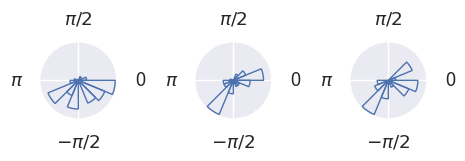

In [ ]:


## 极坐标图像 (results_df, aln_sig, tcr_sig)
POLAR_XTICKS = np.pi / 180.0 * np.array([0, 90, 180, 270])
POLAR_XTICKLABELS = ["0", r"$\pi/2$", r"$\pi$", r"$-\pi/2$"]

SW = {"low_freq": None, "high_freq": 3.0}
SP_FAST = {"low_freq": 12.0, "high_freq": 16.0}
SP_SLOW = {"low_freq": 8.0, "high_freq": 12.0}
SP_FULL = {"low_freq": 8.0, "high_freq": 16.0}

'''
def get_phase(signal, filter_args, pad=None):
    """
    Extract phase of the signal. Steps: detrend -> pad -> filter -> Hilbert
    transform -> get phase -> un-pad.

    :param signal: signal to get phase from
    :type signal: `neurolib.utils.signal.Signal`
    :param filter_args: arguments for `Signal`'s filter method (see its
        docstring)
    :type filter_args: dict
    :param pad: how many seconds to pad, if None, won't pad
    :type pad: float|None
    :return: wrapped Hilbert phase of the signal
    :rtype: `neurolib.utils.signal.Signal`
    """
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase


def get_amplitude(signal, filter_args, pad=None):
    """
    Extract amplitude of the signal. Steps: detrend -> pad -> filter -> Hilbert
    transform -> get amplitude -> un-pad.

    :param signal: signal to get amplitude from
    :type signal: `neurolib.utils.signal.Signal`
    :param filter_args: arguments for `Signal`'s filter method (see its
        docstring)
    :type filter_args: dict
    :param pad: how many seconds to pad, if None, won't pad
    :type pad: float|None
    :return: Hilbert amplitude of the signal
    :rtype: `neurolib.utils.signal.Signal`
    """
    assert isinstance(signal, Signal)
    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude

'''
def so_phase_while_spindle(so_phase, spindle_amp, down_state_centers, **kwargs):
    """
    Compute SO phase on spindle maximum between down states.

    :param so_phase: phase of the SO
    :type so_phase: np.ndarray
    :param spindle_amp: spindle amplitude
    :type spindle_amp: np.ndarray
    :param down_state_centers: indices of down state centers
    :type down_state_centers: np.ndarray
    :return: SO phases on maximum spindle amplitude
    :rtype: np.ndarray
    """
    SOphases = []

    def pairwise(iterable):
        a, b = tee(iterable)
        next(b, None)
        return zip(a, b)

    spindle_amp_threshold = kwargs.get("sp_amp_thresh", 0.0) #5.0)
    for start_idx, end_idx in pairwise(down_state_centers):
        # get amplitude for each down state
        sp_amp_down_state = spindle_amp[start_idx:end_idx]
        # find max sigma amp
        idx_max = sp_amp_down_state.argmax()
        if sp_amp_down_state[idx_max] >= spindle_amp_threshold:
            SOphases.append(so_phase[start_idx + idx_max])

    return np.array(SOphases)

def plot_circular_histogram(
    angles,
    bins=16,
    density=None,
    offset=0.0,
    lab_unit="radians",
    start_zero=False,
    title="",
    ax=None,
):
    """
    Plot circular histogram (rose plot). Expects angles in [-pi, pi].

    :param angles: angles for plotting
    :type angles: np.ndarray|None
    :param bins: number of bins
    :type bins: int
    :param density: if True, area of bin would be proportional to density, if
        False, its height would be proportional, i.e. area would be squared
    :type density: bool
    :param offset: direction of zero angle
    :type offset: float|int
    :param lab_unit: unit of angles: "radians" or "degrees"
    :type lab_unit: str
    :param start_zero: whether to make bins symmetric around 0
    :type start_zero: bool
    :param title: title for the plot
    :type title: str
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="polar")
    # wrap angles to [-pi, pi)
    angles = (angles + np.pi) % (2 * np.pi) - np.pi

    # set bins symmetrically around zero
    if 1: #start_zero:
        # to have a bin edge at zero use an even number of bins
        if bins % 2:
            bins += 1
        bins = np.linspace(-np.pi, np.pi, num=bins + 1)

    count, bin = np.histogram(angles, bins=bins)

    # Compute width of each bin
    widths = np.diff(bin)
    print(widths)
    # By default plot density (frequency potentially misleading)
    if density is None or density is True:
        # Area to assign each bin
        area = count / angles.size
        # Calculate corresponding bin radius
        radius = area
        # radius = (area / np.pi) ** 0.5
    else:
        radius = count

    # Plot data on ax
    ax.bar(
        bin[:-1],
        radius,
        zorder=10,
        align="edge",
        width=widths,
        fill=False,
        edgecolor="C0",
    )
    '''
    angles_mean = circmean(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    angles_std = circstd(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    # mean
    ax.plot([0, angles_mean], [0, np.max(radius)], color="red", linewidth=3.0)
    # mean +- std
    ax.plot(
        [0, angles_mean - angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.plot(
        [0, angles_mean + angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.fill_between(
        np.linspace(angles_mean - angles_std, angles_mean + angles_std, 100),
        0,
        np.max(radius),
        color="red",
        alpha=0.2,
        zorder=1,
    )
    '''
    # set the direction of the zero angle
    ax.set_theta_offset(offset)

    # remove ylabels, they are mostly obstructive and not informative
    ax.set_yticks([])

    if lab_unit == "radians":
        ax.set_xticks(POLAR_XTICKS)
        ax.set_xticklabels(POLAR_XTICKLABELS)
    ax.set_title(title)



# for TF
DS_DETECT_VALUES = {
    "right_border_long": [13.0, 0.05],
    "right_border_short": [10.0, 0.05],
    "left_border": [5.0, 0.3],
    "inside_lc": [10.0, 0.1],
}
MAX_DELAY_DS_SPINDLE = 1.5


ds = dummy_detect_down_states(
        RatesSignal(xr.DataArray(results_df["ALN"])),
        threshold=5,
        min_down_length=0.05,
    )
ds_midpoints = [dss[len(dss) // 2] for dss in ds]

print("ds_midpoints: ", ds_midpoints)
aln_so_phase = get_phase(aln_sig, filter_args=SW, pad=5.0)
print("aln_so_phase: ", aln_so_phase.data.values.min(), aln_so_phase.data.values.max())
print("aln_so_phase: ", aln_so_phase.data.values)
tcr_sp_amp_fast = get_amplitude(tcr_sig, filter_args=SP_FAST, pad=5.0)
tcr_sp_amp_slow = get_amplitude(tcr_sig, filter_args=SP_SLOW, pad=5.0)
tcr_sp_amp_full = get_amplitude(tcr_sig, filter_args=SP_FULL, pad=5.0)
print("tcr_sp_amp_fast: ", tcr_sp_amp_fast.data.values.min(), tcr_sp_amp_fast.data.values.max())
print("tcr_sp_amp_slow: ", tcr_sp_amp_slow.data.values)
tcr_so_phases_fast = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_fast.data.values, ds_midpoints
)
tcr_so_phases_slow = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_slow.data.values, ds_midpoints
)
tcr_so_phases_full = so_phase_while_spindle(
    aln_so_phase.data.values, tcr_sp_amp_full.data.values, ds_midpoints
)
print("tcr_fast: ", tcr_so_phases_fast)
print("tcr_slow: ", tcr_so_phases_slow)

fig = plt.figure(figsize=(5, 17))
gs = fig.add_gridspec(nrows=1, ncols=3)
gs.update(wspace=1, hspace=1.0)
ax0 = fig.add_subplot(gs[0, 0], projection="polar")
plot_circular_histogram(tcr_so_phases_fast, ax=ax0)
ax1 = fig.add_subplot(gs[0, 1], projection="polar")
plot_circular_histogram(tcr_so_phases_slow, ax=ax1)
ax2 = fig.add_subplot(gs[0, 2], projection="polar")
plot_circular_histogram(tcr_so_phases_full, ax=ax2)

In [ ]:
afgjdlksd

NameError: name 'afgjdlksd' is not defined

In [ ]:
# for CFC
from statistical_testing import get_p_values
from xfreq import (
    XFreqEvaluateSignal,
    kullback_leibler_modulation_index,
    mean_vector_length,
    mutual_information,
    phase_locking_value,
)
from neurolib.utils.signal import Signal, RatesSignal 
from utils import dummy_detect_down_states, get_amplitude, get_dummy_so_phase, get_phase
import pandas as pd 
import xarray as xr 
from itertools import tee
# for circ
from scipy.stats import circmean, circstd
from spindle_detection import down_state_to_spindle_pow_max_peak
# for TF
from yasa import get_centered_indices, stft_power
import matplotlib as mpl

SW = {"low_freq": None, "high_freq": 3.0}
SP_FAST = {"low_freq": 12.0, "high_freq": 16.0}
SP_SLOW = {"low_freq": 8.0, "high_freq": 12.0}
SP_FULL = {"low_freq": 8.0, "high_freq": 16.0}
CFC_DF_COLS = ["nodes", "connectivity", "measure", "value", "p-value"]



In [ ]:

# for KL-MI
def so_phase(signal):
    #return get_phase(signal, filter_args=SW, pad=5.0)
    pad = 5.0
    filter_args={"low_freq": None, "high_freq": 3.0}
    #assert isinstance(signal, Signal)

    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase
def spindle_amp_1(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args1)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude
    # return get_amplitude(signal, filter_args=SP, pad=5.0)
def spindle_amp_2(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args2)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude
def spindle_amp_3(signal):
    pad = 5.0
    filter_args1={"low_freq": 12.0, "high_freq": 15.0}
    filter_args2={"low_freq": 8.0, "high_freq": 12.0}
    filter_args3={"low_freq": 8.0, "high_freq": 15.0}


    amplitude = signal.detrend(inplace=False)
    if pad:
        amplitude.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    amplitude.filter(**filter_args3)
    amplitude.hilbert_transform(return_as="amplitude")
    if pad:
        amplitude.sel([amplitude.start_time + pad, amplitude.end_time - pad])
    return amplitude

# In fact, if U don't need to calculate kl-mi, then U don't need to calculate all these three things! 
klmi_1 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_1,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 100, #1000
        "surrogate_type": "shuffle",#"IAAFT",
        #"n_iterations": 10,
    },
    workers=6#6,
)           
klmi_2 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_2,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 100,
        "surrogate_type": "shuffle",#"IAAFT",
        #"n_iterations": 10,
    },
    workers=6#6,
)           

klmi_3 = XFreqEvaluateSignal(
    measure_function=kullback_leibler_modulation_index,
    slow_timeseries_preprocessing=so_phase,
    fast_timeseries_preprocessing=spindle_amp_3,
    measure_settings={"bins": 36, "return_for_plotting": True},
    surrogate_settings={
        "num_surr": 200,
        "surrogate_type": "shuffle",#"IAAFT",
        # "n_iterations": 10,
    },
    workers=6#6,
)           

def klmi_eval_1(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_1.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df
def klmi_eval_2(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_2.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df
def klmi_eval_3(slow_ts, fast_ts, subtype="ALN vs. TCR", baseline="regular"):
    klmi_data, klmi_surrs = klmi_3.run(slow_timeseries=slow_ts, fast_timeseries=fast_ts)
    surrs_values = np.array([surr_result[0] for surr_result in klmi_surrs])
    p_val = get_p_values(klmi_data[0], surrs_values, tailed="upper")
    klmi_val = klmi_data[0]
    df = pd.DataFrame(
        [[subtype, baseline, "KL-MI", klmi_val, p_val]], columns=CFC_DF_COLS
    )
    return klmi_data, klmi_surrs, df

results_df = pd.DataFrame(
    {
        "ALN": Q_e * 1000.0,
        "TCR": Q_t,
    },
    index=t/10000,
)
results_df.index.name = "time"

aln_xr = xr.DataArray(results_df["ALN"])
tcr_xr = xr.DataArray(results_df["TCR"])
aln_sig = RatesSignal(aln_xr)
tcr_sig = RatesSignal(tcr_xr)

klmi_data_1, klmi_surrs_1, df_1 = klmi_eval_1(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")
klmi_data_2, klmi_surrs_2, df_2 = klmi_eval_2(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")

# klmi_data_3, klmi_surrs_3, df_3 = klmi_eval_3(aln_sig, tcr_sig, subtype="ALN vs TCR", baseline="regular")


Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

Setting up band-pass filter from 12 - 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 12.00
- Lower transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 10.50 Hz)
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 11001 samples (1.100 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
d:\mynew\demo_all\models\util\xfreq.py:247: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for _ in range(self.num_surr)


Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
d:\mynew\demo_all\models\util\xfreq.py:247: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for _ in range(self.num_surr)


In [ ]:
print(klmi_data_1[0], klmi_data_2[0]) #,klmi_data_3[0])
# is it too small?

0.002094771506084544 0.0037437419209610375


p: 1.0
p: 1.0


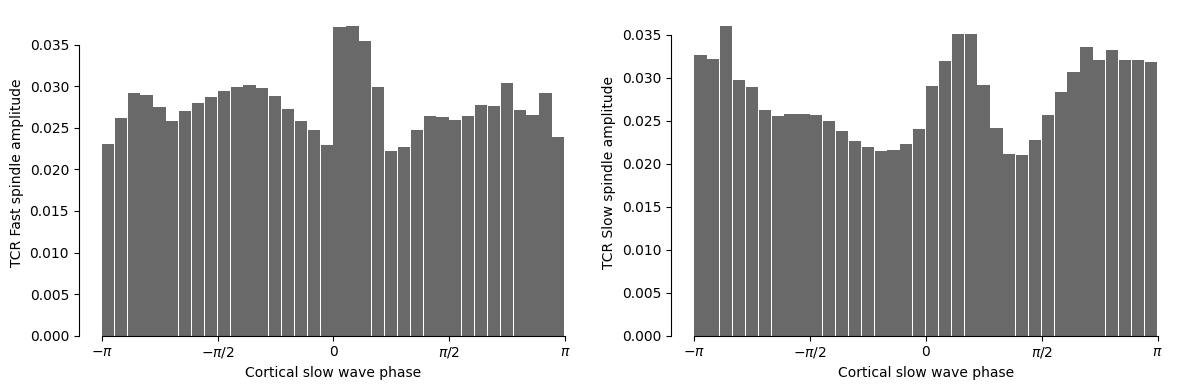

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_kullback_leibler_modulation_index(
    dk_mi_result, surrs=None, ax=None, **kwargs
):
    """
    Plot result of Kullback-Leibler modulation index investigation.

    :param dk_mi_result: result of
        `analysis.x_freq.kullback_leibler_modulation_index` function with
        return_for_plottong set to True, hence DK-MI value and tuple with
        amplitude histogram and phase bins
    :type dk_mi_result: float, (np.ndarray, np.ndarray)
    :param surrs: surrogate values for the same as DK-MI result, passed as a
        list of same values as a results
    :type surrs: list[float, (np.ndarray, np.ndarray)]
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    :kwargs:
        - data_color - color of the hist for data
        - surr_color - color for the mean of surrogate data
        - perc_color - color for the 95th percentile of surrogate distribution
    """
    dkmi_data, (hist_data, bins) = dk_mi_result
    bin_width = np.diff(bins).mean()
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111)
    #if surrs is not None:
    if 0:#surrs != []:
        surr_hist = np.array([surr_result[1][0] for surr_result in surrs])
        surrs_values = np.array([surr_result[0] for surr_result in surrs])
        # plot mean +- SD in surrogate distribution
        ax.bar(
            bins[:-1],
            surr_hist.mean(axis=0),
            yerr=None,  # surr_hist.std(axis=0),
            align="edge",
            width=0.95 * bin_width,
            color=kwargs.pop("surr_color", "#777777"),
            alpha=0.7,
            capsize=5,
        )
        # plot 95th percentile of surrogate distribution
        ax.bar(
            bins[:-1],
            np.percentile(surr_hist, 95.0, axis=0),
            align="edge",
            width=0.95 * bin_width,
            color=kwargs.pop("perc_color", "#222222"),
            alpha=0.7,
        )
        p_val = get_p_values(dkmi_data, surrs_values)

    else:
        p_val = 1.0
    print("p:", p_val) # to calculate among surrs and original_klmi_data

    ax.bar(
        bins[:-1],
        hist_data,
        align="edge",
        width=0.95 * bin_width,
        color=kwargs.pop("data_color", "red"),
        alpha=0.8,
    )
    ax.set_ylabel("Amplitude value")
    ax.set_xticks(np.linspace(-np.pi, np.pi, 5))
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", 0, r"$\pi/2$", r"$\pi$"])
    ax.set_xlabel("Phase bins")
    ax.set_title(
        f"DK-MI value in data: {dkmi_data:.4f}{'*' if p_val < 0.05 else ''}"
    )

def plot_circular_histogram(
    angles,
    bins=16,
    density=None,
    offset=0.0,
    lab_unit="radians",
    start_zero=False,
    title="",
    ax=None,
):
    """
    Plot circular histogram (rose plot). Expects angles in [-pi, pi].

    :param angles: angles for plotting
    :type angles: np.ndarray|None
    :param bins: number of bins
    :type bins: int
    :param density: if True, area of bin would be proportional to density, if
        False, its height would be proportional, i.e. area would be squared
    :type density: bool
    :param offset: direction of zero angle
    :type offset: float|int
    :param lab_unit: unit of angles: "radians" or "degrees"
    :type lab_unit: str
    :param start_zero: whether to make bins symmetric around 0
    :type start_zero: bool
    :param title: title for the plot
    :type title: str
    :param ax: axis to plot to; if None, will create
    :type ax: `matplotlib.axes._axes.Axes`|None
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="polar")
    # wrap angles to [-pi, pi)
    angles = (angles + np.pi) % (2 * np.pi) - np.pi

    # set bins symmetrically around zero
    if start_zero:
        # to have a bin edge at zero use an even number of bins
        if bins % 2:
            bins += 1
        bins = np.linspace(-np.pi, np.pi, num=bins + 1)

    count, bin = np.histogram(angles, bins=bins)

    # Compute width of each bin
    widths = np.diff(bin)

    # By default plot density (frequency potentially misleading)
    if density is None or density is True:
        # Area to assign each bin
        area = count / angles.size
        # Calculate corresponding bin radius
        radius = (area / np.pi) ** 0.5
    else:
        radius = count

    # Plot data on ax
    ax.bar(
        bin[:-1],
        radius,
        zorder=10,
        align="edge",
        width=widths,
        fill=False,
        edgecolor="C0",
    )
    angles_mean = circmean(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    angles_std = circstd(angles, high=np.pi, low=-np.pi, nan_policy="omit")
    # mean
    ax.plot([0, angles_mean], [0, np.max(radius)], color="red", linewidth=3.0)
    # mean +- std
    ax.plot(
        [0, angles_mean - angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.plot(
        [0, angles_mean + angles_std],
        [0, np.max(radius)],
        "--",
        color="red",
        linewidth=1.5,
    )
    ax.fill_between(
        np.linspace(angles_mean - angles_std, angles_mean + angles_std, 100),
        0,
        np.max(radius),
        color="red",
        alpha=0.2,
        zorder=1,
    )
    # set the direction of the zero angle
    ax.set_theta_offset(offset)
    # remove ylabels, they are mostly obstructive and not informative
    ax.set_yticks([])

    if lab_unit == "radians":
        ax.set_xticks(POLAR_XTICKS)
        ax.set_xticklabels(POLAR_XTICKLABELS)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
#fig, axes = plt.subplots(1, 3, figsize=(12,4))
plot_kullback_leibler_modulation_index(
    klmi_data_1,
    klmi_surrs_1,
    ax=axes[0],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(ax=axes[0], trim=True)
axes[0].set_xlabel("Cortical slow wave phase")
axes[0].set_ylabel("TCR Fast spindle amplitude")
axes[0].set_title("")#

plot_kullback_leibler_modulation_index(
    klmi_data_2,
    klmi_surrs_2,
    ax=axes[1],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(ax=axes[1], trim=True)
axes[1].set_xlabel("Cortical slow wave phase")
axes[1].set_ylabel("TCR Slow spindle amplitude")
axes[1].set_title("")#


'''
plot_kullback_leibler_modulation_index(
    klmi_data_3,
    klmi_surrs_3,
    ax=axes[2],
    data_color="#444444",
    surr_color="#AAAAAA",
    perc_color="#AAAAAA",
)
sns.despine(trim=True)
plt.gca().set_xlabel("Cortical slow wave phase")
plt.gca().set_ylabel("TCR spindle amplitude")
plt.gca().set_title("")#
'''
plt.tight_layout()

In [ ]:
print("=========================================================")
agdsads

NameError: name 'agdsads' is not defined

In [ ]:
# Let's get a bool vector indicating for each sample
mask = sp2.get_mask()

# Now let's plot
spindles_highlight = V_t * mask
spindles_highlight[spindles_highlight == 0] = np.nan

plt.figure(figsize=(14, 4))
plt.plot(t, V_t, 'k')
plt.plot(t, spindles_highlight, 'indianred')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([0, t[-1]])
plt.title('N2 sleep EEG data (2 spindles detected)')
sns.despine()
# plt.savefig('detection.png', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t, Q_t, lw=1.5, color='k')
#plt.plot(t, V_t, lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
#plt.xlim([t.min(), t.max()])
plt.xlim([t.min(), t.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:
print(V_e[:100])
#print("ar:", ar_chunk[:100])
#print("br:", br_chunk[:100])
#print("cr:", cr_chunk[:100])
#print("dr:", dr_chunk[:100])
#print("ur:", ur_chunk[:100])
print("Q_r:", Q_r[:100])

NameError: name 't' is not defined

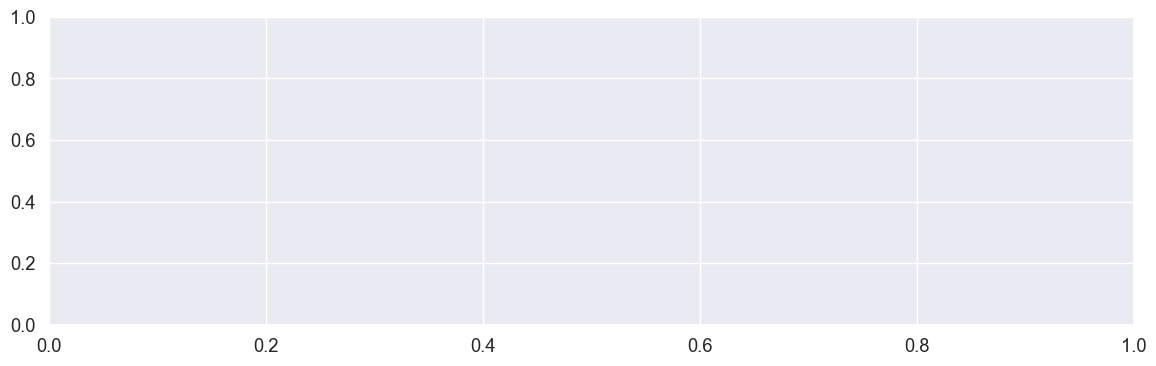

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t[:1000], V_e[:1000], lw=1.5, color='k')
plt.xlabel('Time (mseconds)')
plt.ylabel('Amplitude (mV)')
plt.xlim([t[:1000].min(), t[:1000].max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

parametrization_demo = pp.cartesian_product({
    'p1': [float(round(elem, 3)) for elem in np.linspace(0.5, 2, 2)], #16)],
    'p2': [float(round(elem, 3)) for elem in np.linspace(0.005, 0.02, 2)], #16)],
    'model': ['spindle3']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [ ]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'abcde.hdf') # for params.p1 etc.

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

number of cores: 28


In [ ]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

Done.


In [ ]:
#import requests
#ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:
traj.f_get_parameters()


{'parameters.dt': <Parameter parameters.dt: 0.0001>,
 'parameters.duration': <Parameter parameters.duration: 30>,
 'parameters.model': <Parameter parameters.model (len:4): 'spindle3'>,
 'parameters.seed': <Parameter parameters.seed: 0>,
 'parameters.c2tsc': <Parameter parameters.c2tsc: -5.0>,
 'parameters.p1': <Parameter parameters.p1 (len:4): 1.0>,
 'parameters.p2': <Parameter parameters.p2 (len:4): 0.008>,
 'parameters.p3': <Parameter parameters.p3: 64.0>,
 'parameters.p4': <Parameter parameters.p4: 4.0>,
 'parameters.tau_t': <Parameter parameters.tau_t: 0.044>,
 'parameters.tau_r': <Parameter parameters.tau_r: 0.022>,
 'parameters.f_t_max': <Parameter parameters.f_t_max: 250>,
 'parameters.f_r_max': <Parameter parameters.f_r_max: 200>,
 'parameters.f_t_th': <Parameter parameters.f_t_th: 50>,
 'parameters.f_r_th': <Parameter parameters.f_r_th: 110>,
 'parameters.gamma_t': <Parameter parameters.gamma_t: 0.008>,
 'parameters.gamma_r': <Parameter parameters.gamma_r: 0.008>,
 'parameters

In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.p1'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.p2'].f_get_range()
print(b)



0.0001
[0.5, 0.5, 2.0, 2.0]
[0.005, 0.02, 0.005, 0.02]


In [ ]:
len(traj.results.spindle3_results_for_abcde[0].V_t)
traj.f_get_results()
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

{'results.spindle3_results_for_abcde.run_00000003': <Result results.spindle3_results_for_abcde.run_00000003>,
 'results.spindle3_results_for_abcde.run_00000002': <Result results.spindle3_results_for_abcde.run_00000002>,
 'results.spindle3_results_for_abcde.run_00000001': <Result results.spindle3_results_for_abcde.run_00000001>,
 'results.spindle3_results_for_abcde.run_00000000': <Result results.spindle3_results_for_abcde.run_00000000: V_e=array([  1.        ,   1.        ,   1.        , ..., -62...>}

In [ ]:
len(traj.results.spindle3_results_for_abcde[0].V_t)
traj.f_get_results()
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

{'results.spindle3_results_for_abcde.run_00000003': <Result results.spindle3_results_for_abcde.run_00000003>,
 'results.spindle3_results_for_abcde.run_00000002': <Result results.spindle3_results_for_abcde.run_00000002>,
 'results.spindle3_results_for_abcde.run_00000001': <Result results.spindle3_results_for_abcde.run_00000001>,
 'results.spindle3_results_for_abcde.run_00000000': <Result results.spindle3_results_for_abcde.run_00000000: V_e=array([  1.        ,   1.        ,   1.        , ..., -62...>}

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

import yasa
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s

def cal_spindles(i):
    sp = yasa.spindles_detect(traj.results.thalamus_results[i].V_t[0], sf)
    rate = len(sp._events) / duration if sp else 0
    return rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_spindles)(i) for i in tqdm(range(len(dfResults))))
print(plot_results)


In [ ]:
import matplotlib.pyplot as plt

g_LK = np.unique(dfResults['g_LK'])
g_h = np.unique(dfResults['g_h'])
plot_results_matrix = np.reshape(plot_results, (len(g_LK), len(g_h)))

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[g_LK[0], g_LK[-1], g_h[0], g_h[-1]])

plt.xlabel("g_LK", fontsize=30)
plt.ylabel("g_h", fontsize=30)
plt.clim(0, 0.3)
cbar = plt.colorbar(label="spindles", extend='max')
plt.show()

In [ ]:
# spindle detection
import yasa
import logging
def scale_to_voltage(dataarray, feature_range=(-80, -20)):
    data_scale = (feature_range[1]- feature_range[0]) / (
        dataarray.max(dim="time") - dataarray.min(dim="time")
    )
    data_min = feature_range[0] - dataarray.min(dim="time") * data_scale
    return data_scale * dataarray + data_min
def spindles_detect_thalamus(tcr_ts, trn_ts=None, trn_median_thresh=5.0, **kwargs):
    assert tcr_ts.ndim == 1, "Only works on 1D timeseries"
    if tcr_ts.max() < 10.0 or tcr_ts.std() < 5.0:
        logging.warning("No spindles found: STD too low")
        return None
    if trn_ts is not None and np.nanmedian(trn_ts) < trn_median_thresh:
        logging.warning("No spindles found: TRN is not oscillating")
        return None
    sf = float(1.0 / (tcr_ts.time[1] - tcr_ts.time[0]))
    return yasa.spindles_detect(
        scale_to_voltage(tcr_ts).values, sf=sf, **kwargs
    )


In [ ]:
import yasa
import xarray as xr
# print(V_t)
print("V_t.shape:", V_t.shape)
data = np.diff(V_t[0]) * 1000  # pay attention to the unit(mV or uV)
# print(data)
print(data.shape)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

t1 = t[2000000:3000000] / 1000
print(t1.shape)
data1 = data[2000000:3000000]
print(data1.shape)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t1, data1, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t1.min(), t1.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

coords = t1
# 7000
tcr_ts = xr.DataArray(data1, coords=[coords], dims=['time'])

sf = 100000 # !!!  1000,000 data for 10 seconds
sp = yasa.spindles_detect(tcr_ts, sf, duration=(0.3, 2))
sp.summary()



In [ ]:

import xarray as xr
data = traj.results.thalamus_results[0].V_t[0][:-1] *1000 # pay attention to the unit(mV or uV)
coords = traj.results.thalamus_results[0].t
# 7000
tcr_ts = xr.DataArray(data, coords=[coords], dims=['time'])

sf = 200
sp = yasa.spindles_detect(tcr_ts, sf)
sp.summary()
